# `ltm` — Yperman's (2007) Link Transmission Model

**What.** `ltm` is the Newell-Daganzo cumulative-curve loading method as a
`LinkModel`: sending reads Newell's shifted UPSTREAM curve `L/vf` ahead (the
point-queue look-ahead), and receiving adds a finite backward wave — storage
freed by a downstream departure reappears at the upstream end `L/w` later. It is
STATELESS beyond the base cumulative curves (no cells, `_advance_state` is a
no-op): the whole link is evaluated by exact interpolation of piecewise-linear
curves, not a grid of cell averages.

**Why it is in the benchmark.** It is `ctm`'s cumulative-curve twin — same
sending/receiving interface, same physics, but no CFL = 1 cell-alignment
requirement, only a wave-resolved grid `dt <= min(L/vf, L/w)`. On any scenario
where both are exact it must reproduce `ctm`'s boundary curves byte-for-byte;
its concrete advantage is running on grids `CTMLink` rejects outright. See the
[model compendium](../../docs/MODELS.md) (Yperman 2007) and
[docs/design/adr-016-ltm.md](../../docs/design/adr-016-ltm.md) (P1).

**Scope.** This notebook loads the same built-in
`triangular_bottleneck_dynamic_scenario` as `ctm` through `LTMLink`, certifies
it, and cross-checks the two models' cumulative curves. It also demonstrates
LTM's grid flexibility on a link `CTMLink` cannot load at all.

**Canon.** `[yperman2007link]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `DNLEvaluator` from the
cumulative link curves the loader emitted, in the cell where it is claimed. LTM
has no self-report to diff — like `ctm`, `NetworkLoader.run()` is a
deterministic, one-shot forward simulation
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `ltm` is a core DNL link model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based (headless
# CI renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it
# silently suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    CTMLink,
    DNLEvaluator,
    DynamicDemand,
    DynamicScenario,
    LinkDynamics,
    LTMLink,
    NetworkLoader,
    TimeGrid,
    triangular_bottleneck_dynamic_scenario,
    viz,
)
from tabench.core.scenario import Network

## The scenario

The same built-in `triangular_bottleneck_dynamic_scenario` `ctm` runs on
(symmetric `vf = w = 1`, `kappa = 4`, capacities `[2, 0.5]`, arrival rate 1.5) —
both link models exact on this instance, so it is the fair cross-check anchor.

In [2]:
scenario = triangular_bottleneck_dynamic_scenario()
net = scenario.network
edges = scenario.grid.edges
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"grid          : dt={scenario.grid.dt}, n_steps={scenario.grid.n_steps}")
print("task          : deterministic DNL loading (feasibility + conservation + shock)")

scenario      : dnl-triangular-bottleneck
content hash  : d4148843c3292e42…
links         : 2  (tail→head: 1->3, 3->2)
grid          : dt=1.0, n_steps=12
task          : deterministic DNL loading (feasibility + conservation + shock)


## Load the network

`LTMLink` needs only a finite jam density — no cell-alignment requirement — so
the SAME `NetworkLoader` contract that ran `ctm` runs `ltm` unchanged.

In [3]:
out = NetworkLoader(scenario, LTMLink).run()
print(f"link model        : {LTMLink.__name__}")
print(f"emitted n_in[0]    : {np.round(out.n_in[0, ::4], 3)}  (every 4th edge)")
print(f"emitted n_out[0]   : {np.round(out.n_out[0, ::4], 3)}  (every 4th edge)")
print(f"storage at t={edges[-1]:.0f}      : {out.n_in[0, -1] - out.n_out[0, -1]:.3f}")

link model        : LTMLink
emitted n_in[0]    : [ 0.  6. 12. 18.]  (every 4th edge)
emitted n_out[0]   : [0. 0. 2. 4.]  (every 4th edge)
storage at t=12      : 14.000


## Certify (P1) — feasibility, conservation, and byte-exact agreement with `ctm`

Both models are exact on this symmetric FD at CFL = 1, so LTM must reproduce
CTM's cumulative curves to machine precision — this is the distinctive LTM
result, recomputed here by actually RUNNING `ctm` again in this cell (not
quoting `01-ctm`'s numbers) and diffing.

In [4]:
metrics = DNLEvaluator(scenario).evaluate(out)
print(f"dnl_feasible            : {metrics['dnl_feasible']:.0f}")
print(f"conservation_residual   : {metrics['conservation_residual']:.3e}")
print(f"storage_residual        : {metrics['storage_residual']:.3e}")
assert metrics["dnl_feasible"] == 1.0
assert metrics["conservation_residual"] <= 1e-9
assert metrics["storage_residual"] <= 1e-9

# The RH-shock boundary anchor, recomputed from the physical parameters exactly
# as in 01-ctm.ipynb (not quoted from it).
expected_n_in = 1.5 * edges
expected_n_out = np.maximum(0.0, 0.5 * (edges - 4.0))
np.testing.assert_allclose(out.n_in[0], expected_n_in, atol=1e-9)
np.testing.assert_allclose(out.n_out[0], expected_n_out, atol=1e-9)
print("boundary curves match the recomputed RH-shock anchor exactly (atol=1e-9)")

# DISTINCTIVE: byte-exact agreement with ctm, RE-RUN here (not quoted).
ctm_out = NetworkLoader(scenario, CTMLink).run()
np.testing.assert_array_equal(out.n_in, ctm_out.n_in)
np.testing.assert_array_equal(out.n_out, ctm_out.n_out)
print("ltm reproduces ctm's cumulative curves byte-for-byte "
      f"(max diff {np.abs(out.n_in - ctm_out.n_in).max():.1f})")

dnl_feasible            : 1
conservation_residual   : 0.000e+00
storage_residual        : 0.000e+00
boundary curves match the recomputed RH-shock anchor exactly (atol=1e-9)
ltm reproduces ctm's cumulative curves byte-for-byte (max diff 0.0)


## LTM's advantage: grids `ctm` cannot load

`CTMLink` requires a cell-aligned length `L = n * vf * dt`; `LTMLink` only needs
`dt <= min(L/vf, L/w)` (wave-resolved). A single link with `L=3`, `vf=2`, `dt=1`
gives `L/vf = 1.5` — not an integer, so `CTMLink` refuses it outright, while
`LTMLink` free-flow-translates it exactly via the exact cumulative-curve
interpolation (recomputed here, not quoted).

In [5]:
unaligned_net = Network(
    name="ltm-unaligned", n_nodes=2, n_zones=2, first_thru_node=1,
    init_node=np.array([1], dtype=np.int64), term_node=np.array([2], dtype=np.int64),
    capacity=np.ones(1), length=np.zeros(1), free_flow_time=np.ones(1),
    b=np.zeros(1), power=np.ones(1), toll=np.zeros(1), link_type=np.ones(1, dtype=np.int64),
)
rates = np.zeros((1, 2, 2))
rates[0, 0, 1] = 1.0
unaligned = DynamicScenario(
    name="ltm-unaligned", network=unaligned_net,
    dynamics=LinkDynamics(
        length=np.array([3.0]), free_speed=np.array([2.0]), wave_speed=np.array([1.0]),
        jam_density=np.array([3.0]), capacity=np.array([2.0]),
    ),
    demand=DynamicDemand(breakpoints=np.array([0.0, 4.0]), rates=rates),
    grid=TimeGrid(dt=1.0, n_steps=10),
)

try:
    NetworkLoader(unaligned, CTMLink).run()
    raise AssertionError("expected CTMLink to reject the unaligned length")
except ValueError as exc:
    print(f"CTMLink refuses this link: {exc}")

u_out = NetworkLoader(unaligned, LTMLink).run()
u_edges = unaligned.grid.edges
u_expected = np.minimum(np.maximum(u_edges - 1.5, 0.0), 4.0)  # free-flow lag L/vf = 1.5
np.testing.assert_allclose(u_out.n_out[0], u_expected, atol=1e-12)
u_metrics = DNLEvaluator(unaligned).evaluate(u_out)
assert u_metrics["dnl_feasible"] == 1.0
print("LTM loads the unaligned link exactly (L/vf = 1.5 lag) where CTM cannot")

CTMLink refuses this link: CTMLink needs a cell-aligned length L = n*vf*dt (CFL = 1): L=3.0, vf*dt=2.0 give 1.5 cells, not an integer >= 1
LTM loads the unaligned link exactly (L/vf = 1.5 lag) where CTM cannot


## Visualize

Both figures come from `tabench.viz`, the house visualizer. Left/top: the
certified bottleneck network coloured by each link's time-averaged flow.
Right/bottom: LTM's average flow against CTM's — every point sits on `y = x`
(the byte-exact agreement certified above).

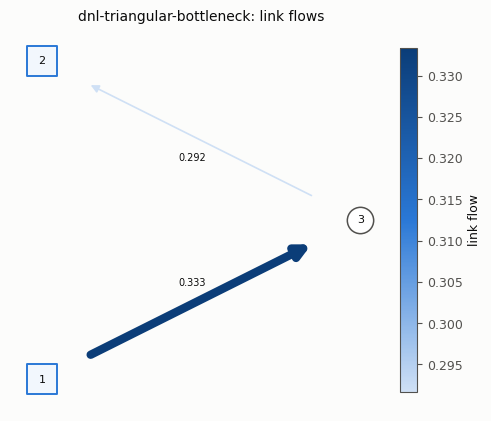

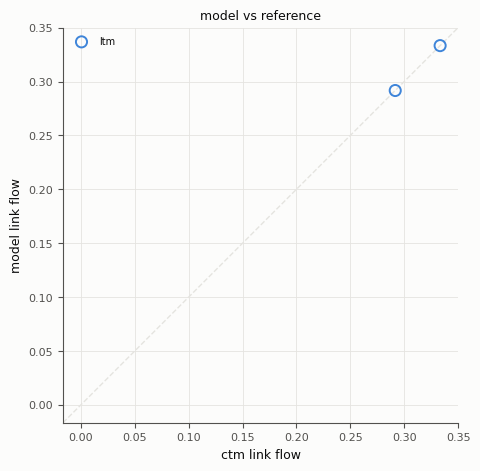

In [6]:
T = float(edges[-1])
ltm_avg = out.n_out[:, -1] / T
ctm_avg = ctm_out.n_out[:, -1] / T

display(viz.plot_network_flows(net, ltm_avg))
display(viz.plot_flow_scatter(("ctm", ctm_avg), {"ltm": ltm_avg}))

## Takeaways & pointers

- **Certified, not self-reported.** DNL link models have nothing to self-report
  — the boundary curves above ARE the emitted output, recertified from scratch
  by `DNLEvaluator`.
- **Exact where both are exact, flexible where `ctm` is not.** LTM's cumulative-
  curve evaluation carries no interior discretisation, so it needs no CFL = 1
  cell alignment — the concrete win demonstrated above.
- **Where next.** the cell-based twin [`ctm`](01-ctm.ipynb); the smooth
  non-triangular FD [`godunov`](03-godunov.ipynb) (built on the same `ctm` cell
  update); merges/diverges [`node-model`](04-node-model.ipynb); the lineage in
  the [model compendium](../../docs/MODELS.md).